In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [131]:
def clean_stock_data(file_path):
    # Load dataset
    df = pd.read_csv(file_path)

    print("Original shape:", df.shape)

    # Convert Date column to datetime
    df["Date"] = pd.to_datetime(df["Date"])

    # Sort from oldest to newest
    df = df.sort_values("Date").reset_index(drop=True)

    # Check and remove duplicate rows
    duplicate_rows = df.duplicated().sum()
    print("Duplicate rows:", duplicate_rows)

    df = df.drop_duplicates()

    # Check and remove duplicate dates
    duplicate_dates = df.duplicated(subset=["Date"]).sum()
    print("Duplicate dates:", duplicate_dates)

    df = df.drop_duplicates(subset=["Date"], keep="first")

    # Check missing values
    print("\nMissing values before handling:")
    print(df.isnull().sum())

    # Handle missing values
    price_columns = [
        "Open",
        "High",
        "Low",
        "Close",
        "Adj Close"
    ]

    df[price_columns] = df[price_columns].ffill()
    df[price_columns] = df[price_columns].bfill()

    # Remove observations with missing Volume
    df = df.dropna(subset=["Volume"])

    # Final validation
    df = df.sort_values("Date").reset_index(drop=True)

    print("\nMissing values after handling:")
    print(df.isnull().sum())

    print("\nFinal shape:", df.shape)

    return df

In [132]:
print("===== AAPL =====")
aapl = clean_stock_data("Dataset/AAPL_historical_data.csv")

print("\n===== NVDA =====")
nvda = clean_stock_data("Dataset/NVDA_historical_data.csv")

print("\n===== JPM =====")
jpm = clean_stock_data("Dataset/JPM_historical_data.csv")

print("\n===== BHP =====")
bhp = clean_stock_data("Dataset/BHP.AX_historical_data.csv")

print("\n===== CBA =====")
cba = clean_stock_data("Dataset/CBA.AX_historical_data.csv")

print("\n===== GMG =====")
gmg = clean_stock_data("Dataset/GMG.AX_historical_data.csv")

===== AAPL =====
Original shape: (2010, 7)
Duplicate rows: 0
Duplicate dates: 0

Missing values before handling:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Missing values after handling:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Final shape: (2010, 7)

===== NVDA =====
Original shape: (2010, 7)
Duplicate rows: 0
Duplicate dates: 0

Missing values before handling:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Missing values after handling:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Final shape: (2010, 7)

===== JPM =====
Original shape: (2010, 7)
Duplicate rows: 0
Duplicate dates: 0

Missing values before handling:
Date         0
Open         0
High         0
Low          0
Close        0
A

In [133]:
print(aapl.head())
print(aapl.tail())

        Date   Open   High    Low  Close  Adj Close     Volume
0 2018-01-02  42.54  43.08  42.31  43.06      40.23  102223600
1 2018-01-03  43.13  43.64  42.99  43.06      40.23  118071600
2 2018-01-04  43.13  43.37  43.02  43.26      40.41   89738400
3 2018-01-05  43.36  43.84  43.26  43.75      40.87   94640000
4 2018-01-08  43.59  43.90  43.48  43.59      40.72   82271200
           Date    Open    High     Low   Close  Adj Close    Volume
2005 2025-12-23  270.84  272.50  269.56  272.36     271.62  29642000
2006 2025-12-24  272.34  275.43  272.20  273.81     273.07  17910600
2007 2025-12-26  274.16  275.37  272.86  273.40     272.66  21521800
2008 2025-12-29  272.69  274.36  272.35  273.76     273.02  23715200
2009 2025-12-30  272.81  274.08  272.28  273.08     272.34  22139600


In [134]:
print(nvda.head())
print(nvda.tail())

        Date  Open  High   Low  Close  Adj Close     Volume
0 2018-01-02  4.89  4.99  4.86   4.98       4.92  355616000
1 2018-01-03  5.10  5.34  5.09   5.31       5.25  914704000
2 2018-01-04  5.39  5.45  5.32   5.34       5.27  583268000
3 2018-01-05  5.35  5.42  5.28   5.39       5.32  580124000
4 2018-01-08  5.51  5.62  5.46   5.55       5.48  881216000
           Date    Open    High     Low   Close  Adj Close     Volume
2005 2025-12-23  182.97  189.33  182.90  189.21     188.98  174873600
2006 2025-12-24  187.94  188.91  186.59  188.61     188.38   65528500
2007 2025-12-26  189.92  192.69  188.00  190.53     190.30  139740300
2008 2025-12-29  187.71  188.76  185.91  188.22     187.99  120006100
2009 2025-12-30  188.24  188.99  186.93  187.54     187.31   97687300


In [135]:
print(jpm.head())
print(jpm.tail())

        Date    Open    High     Low   Close  Adj Close    Volume
0 2018-01-02  107.63  108.02  106.81  107.95      85.52  13578800
1 2018-01-03  107.86  108.49  107.48  108.06      85.60  11901000
2 2018-01-04  108.36  110.03  108.20  109.04      86.83  12953700
3 2018-01-05  109.26  109.55  107.78  108.34      86.27  14155000
4 2018-01-08  108.15  108.68  107.70  108.50      86.40  12466500
           Date    Open    High     Low   Close  Adj Close   Volume
2005 2025-12-23  323.61  327.78  323.09  325.93     321.37  6668300
2006 2025-12-24  326.24  329.99  325.50  329.17     324.56  4289300
2007 2025-12-26  329.11  330.86  326.54  327.91     323.32  4158300
2008 2025-12-29  327.00  327.77  323.53  323.75     319.22  8635300
2009 2025-12-30  324.81  324.94  322.49  323.42     318.89  7904300


In [136]:
print(bhp.head())
print(bhp.tail())

        Date   Open   High    Low  Close  Adj Close   Volume
0 2018-01-02  26.27  26.49  26.27  26.43      14.42  3653331
1 2018-01-03  26.93  27.02  26.86  26.87      14.66  7624353
2 2018-01-04  27.09  27.25  26.98  27.01      14.74  6178215
3 2018-01-05  27.29  27.33  27.17  27.23      14.86  6553946
4 2018-01-08  27.20  27.30  27.10  27.20      14.84  3677542
           Date   Open   High    Low  Close  Adj Close   Volume
2019 2025-12-22  44.85  45.17  44.72  45.07      44.23  5527196
2020 2025-12-23  45.60  45.71  45.30  45.58      44.73  4534942
2021 2025-12-24  45.78  45.78  45.50  45.62      44.77  2112731
2022 2025-12-29  45.90  46.03  45.45  45.45      44.60  4680346
2023 2025-12-30  44.80  45.39  44.70  45.10      44.26  4171339


In [137]:
print(cba.head())
print(cba.tail())

        Date   Open   High    Low  Close  Adj Close   Volume
0 2018-01-02  80.30  80.33  79.78  80.22      55.57  1284609
1 2018-01-03  80.47  80.64  80.06  80.14      55.51  1349269
2 2018-01-04  80.48  80.48  79.81  79.97      55.40  1596303
3 2018-01-05  80.54  81.25  80.37  81.16      56.22  2208531
4 2018-01-08  81.40  81.75  81.30  81.62      56.54  1293549
           Date    Open    High     Low   Close  Adj Close   Volume
2019 2025-12-22  158.00  159.68  157.24  158.26     153.58  1396340
2020 2025-12-23  158.55  161.80  158.55  161.73     156.95  1520620
2021 2025-12-24  161.33  161.50  160.33  161.39     156.62   653329
2022 2025-12-29  161.31  162.24  160.49  160.49     155.74  1091076
2023 2025-12-30  162.25  163.10  161.09  161.29     156.52   995378


In [138]:
print(gmg.head())
print(gmg.tail())

        Date  Open  High   Low  Close  Adj Close   Volume
0 2018-01-02  8.40  8.48  8.34   8.44       7.40  1519605
1 2018-01-03  8.44  8.47  8.36   8.43       7.39  1625146
2 2018-01-04  8.47  8.49  8.39   8.47       7.42  2691250
3 2018-01-05  8.48  8.49  8.35   8.39       7.35  3161786
4 2018-01-08  8.40  8.45  8.37   8.39       7.35  2335220
           Date   Open   High    Low  Close  Adj Close   Volume
2019 2025-12-22  29.09  29.31  28.88  29.22      28.94  2211236
2020 2025-12-23  30.91  31.92  30.68  31.63      31.33  5097836
2021 2025-12-24  31.51  31.67  31.20  31.65      31.35  2150732
2022 2025-12-29  31.54  31.57  30.98  31.32      31.02  2941775
2023 2025-12-30  31.64  31.87  30.77  30.95      30.80  2934635


In [139]:
# Storing all cleaned stock datasets in one dictionary
stocks = {
    "AAPL": aapl,
    "NVDA": nvda,
    "JPM": jpm,
    "BHP": bhp,
    "CBA": cba,
    "GMG": gmg
}

In [140]:
# Storing the summary
summary = []

for stock_name, df in stocks.items():
    
    summary.append({
        "Stock": stock_name,
        "Rows": len(df),
        "Start Date": df["Date"].min(),
        "End Date": df["Date"].max(),
        "Missing Values": df.isnull().sum().sum(),
        "Duplicate Rows": df.duplicated().sum()
    })

# Converting result into a dataframe
summary_df = pd.DataFrame(summary)

summary_df

,Stock,Rows,Start Date,End Date,Missing Values,Duplicate Rows
0,AAPL,2010,2018-01-02,2025-12-30,0,0
1,NVDA,2010,2018-01-02,2025-12-30,0,0
2,JPM,2010,2018-01-02,2025-12-30,0,0
3,BHP,2024,2018-01-02,2025-12-30,0,0
4,CBA,2024,2018-01-02,2025-12-30,0,0
5,GMG,2024,2018-01-02,2025-12-30,0,0


In [141]:
# Summary statistics for each stock
for stock_name, df in stocks.items():
    
    print("\n", stock_name)
    
    print(df[
        ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
    ].describe())


 AAPL
              Open         High          Low        Close    Adj Close  \
count  2010.000000  2010.000000  2010.000000  2010.000000  2010.000000   
mean    137.498756   139.022338   136.103622   137.632085   135.080836   
std      66.203729    66.845908    65.621446    66.269856    66.581243   
min      35.990000    36.430000    35.500000    35.550000    33.710000   
25%      66.500000    67.170000    65.777500    66.625000    64.207500   
50%     145.510000   147.230000   144.105000   145.860000   142.545000   
75%     184.395000   186.490000   182.642500   184.742500   182.357500   
max     286.200000   288.620000   283.300000   286.190000   285.410000   

             Volume  
count  2.010000e+03  
mean   9.446075e+07  
std    5.446452e+07  
min    1.791060e+07  
25%    5.564338e+07  
50%    8.098160e+07  
75%    1.151486e+08  
max    4.265100e+08  

 NVDA
              Open         High          Low        Close    Adj Close  \
count  2010.000000  2010.000000  2010.000000  2

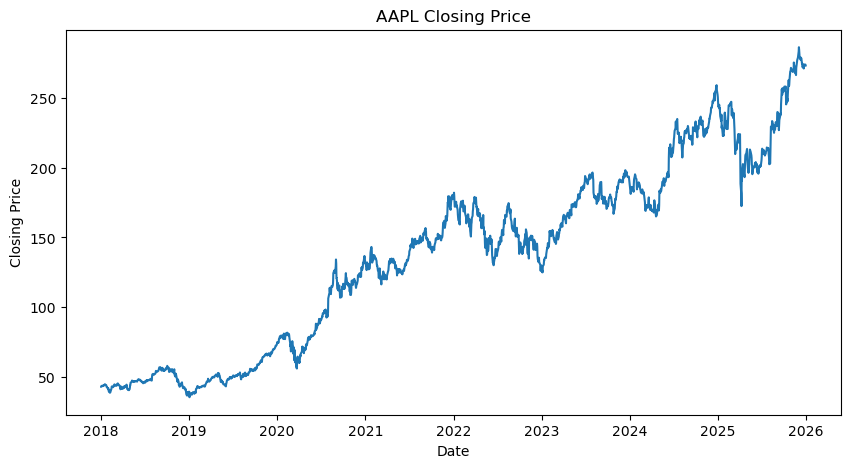

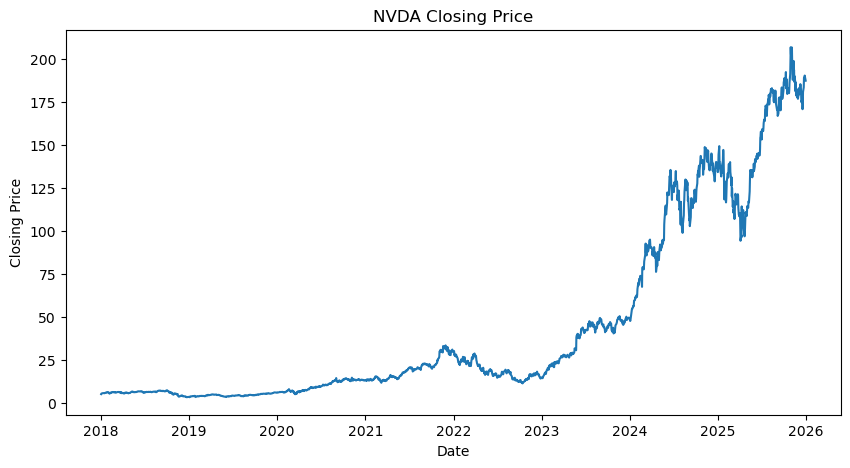

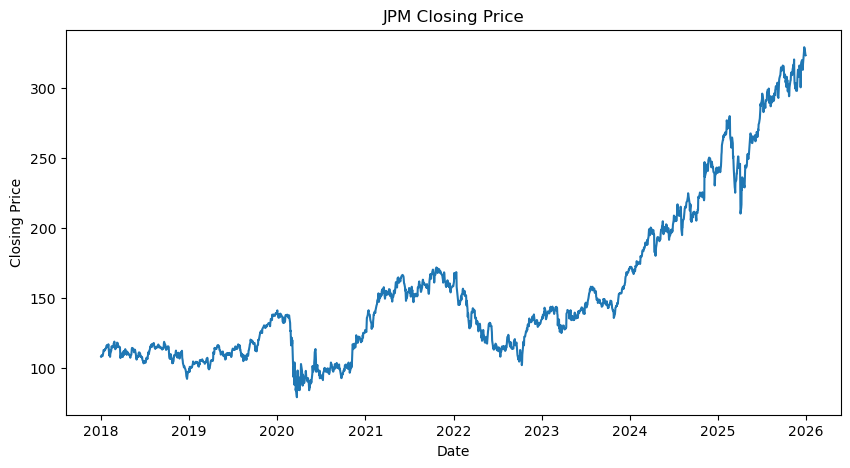

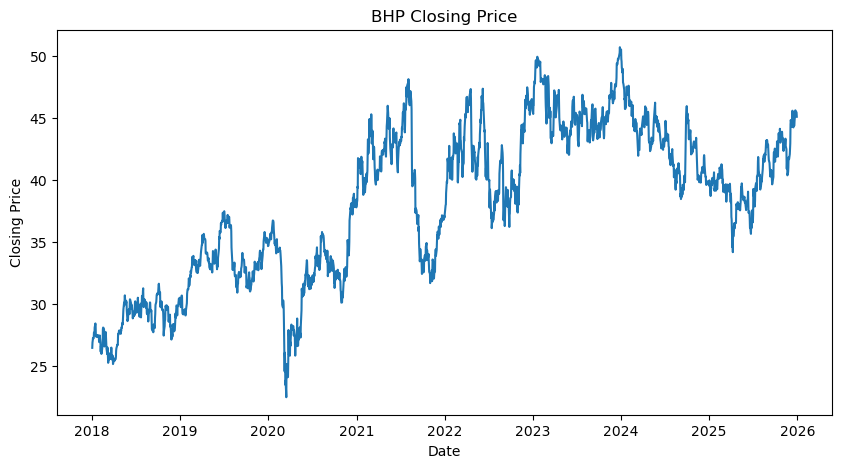

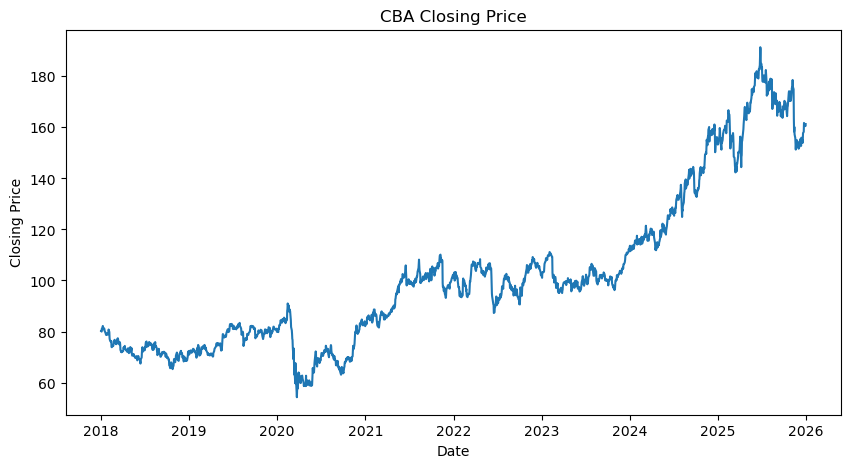

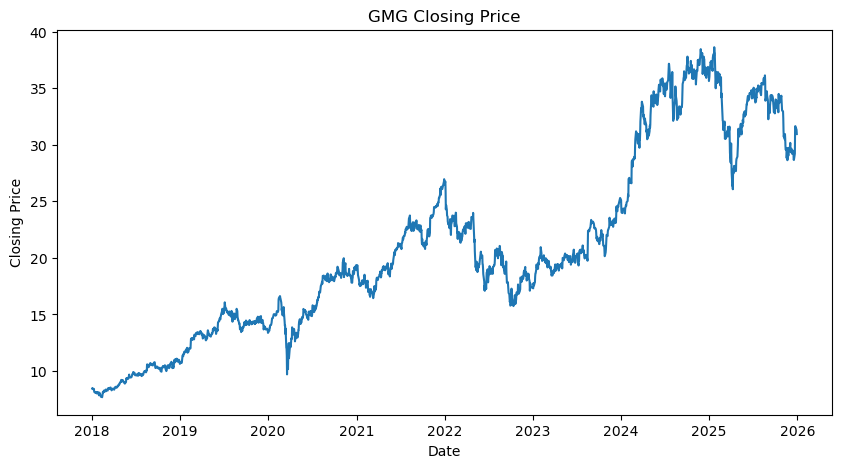

In [142]:
# Plotting the closing price over time
for stock_name, df in stocks.items():
    
    plt.figure(figsize=(10, 5))
    
    plt.plot(df["Date"], df["Close"])
    
    plt.title(stock_name + " Closing Price")
    plt.xlabel("Date")
    plt.ylabel("Closing Price")
    
    plt.show()

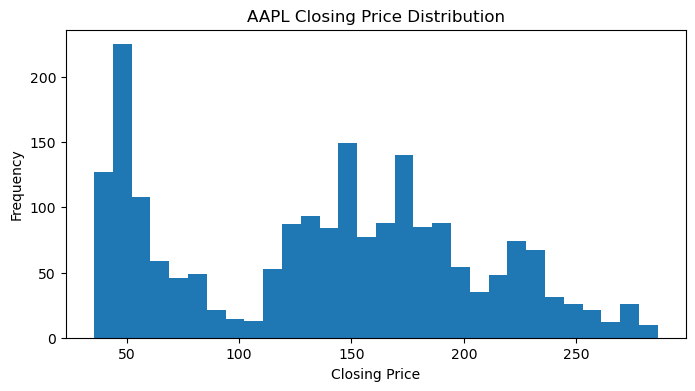

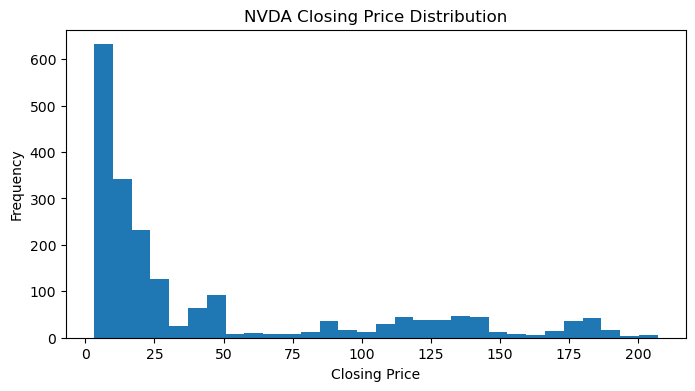

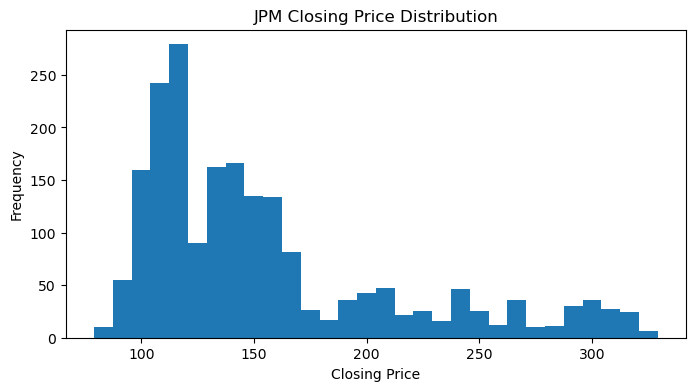

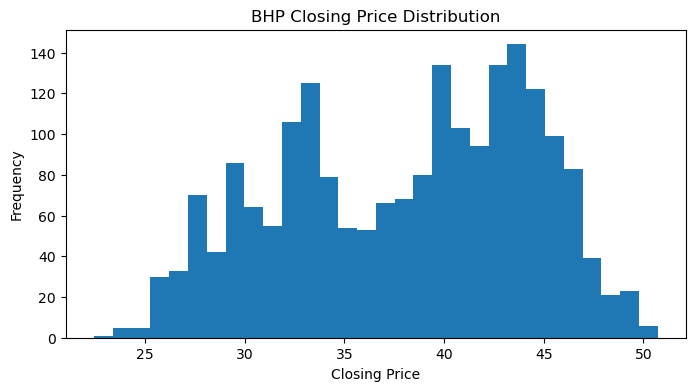

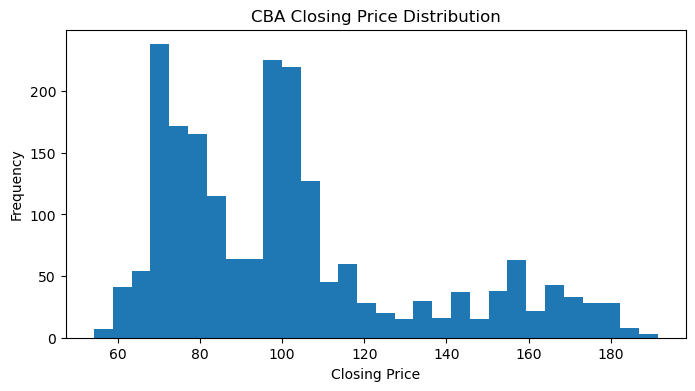

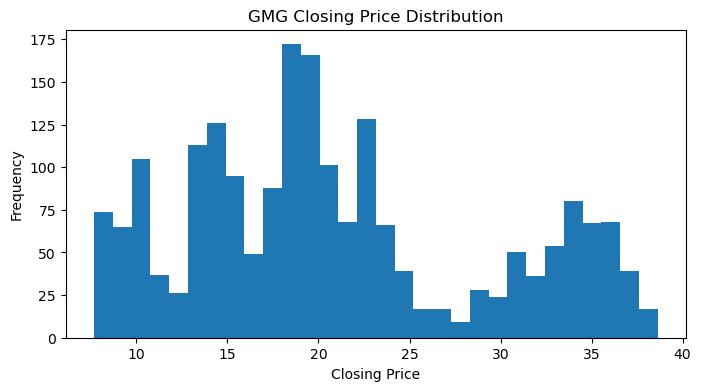

In [143]:
# Distribution of closing prices
for stock_name, df in stocks.items():
    
    plt.figure(figsize=(8, 4))
    
    plt.hist(df["Close"], bins=30)
    
    plt.title(stock_name + " Closing Price Distribution")
    plt.xlabel("Closing Price")
    plt.ylabel("Frequency")
    
    plt.show()

In [144]:
# Checking IQR outliers in closing prices
for stock_name, df in stocks.items():

    Q1 = df["Close"].quantile(0.25)
    Q3 = df["Close"].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df["Close"] < lower_limit) |
        (df["Close"] > upper_limit)
    ]

    print(stock_name)
    print("Lower limit:", round(lower_limit, 2))
    print("Upper limit:", round(upper_limit, 2))
    print("Number of outliers:", len(outliers))
    print()

AAPL
Lower limit: -110.55
Upper limit: 361.92
Number of outliers: 0

NVDA
Lower limit: -57.95
Upper limit: 114.0
Number of outliers: 347

JPM
Lower limit: 27.94
Upper limit: 255.69
Number of outliers: 191

BHP
Lower limit: 17.13
Upper limit: 59.12
Number of outliers: 0

CBA
Lower limit: 24.41
Upper limit: 164.26
Number of outliers: 143

GMG
Lower limit: -1.43
Upper limit: 41.22
Number of outliers: 0



In [145]:
# Checking date range of IQR outliers
for stock_name, df in stocks.items():

    Q1 = df["Close"].quantile(0.25)
    Q3 = df["Close"].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df["Close"] < lower_limit) |
        (df["Close"] > upper_limit)
    ]

    if len(outliers) > 0:
        print(stock_name)
        print("Number of outliers:", len(outliers))
        print("First outlier:", outliers["Date"].min())
        print("Last outlier:", outliers["Date"].max())
        print()

NVDA
Number of outliers: 347
First outlier: 2024-05-29 00:00:00
Last outlier: 2025-12-30 00:00:00

JPM
Number of outliers: 191
First outlier: 2025-01-17 00:00:00
Last outlier: 2025-12-30 00:00:00

CBA
Number of outliers: 143
First outlier: 2025-02-12 00:00:00
Last outlier: 2025-11-10 00:00:00



In [146]:
# Add technical indicators and lagged features to the stock dataset for analysis and modelling
def add_features(df):
    df = df.copy()

    # Daily percentage return
    df["Return"] = df["Close"].pct_change()

    # Simple Moving Averages
    df["SMA_10"] = df["Close"].rolling(window=10).mean()
    df["SMA_20"] = df["Close"].rolling(window=20).mean()

    # Exponential Moving Average
    df["EMA_10"] = df["Close"].ewm(span=10, adjust=False).mean()

    # Rolling volatility
    df["Volatility_10"] = df["Return"].rolling(window=10).std()

    # Previous-day close
    df["Close_Lag_1"] = df["Close"].shift(1)

    # Previous-day return
    df["Return_Lag_1"] = df["Return"].shift(1)

    # RSI - Relative Strength Index
    rsi_period = 14

    delta = df["Close"].diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=rsi_period).mean()
    avg_loss = loss.rolling(window=rsi_period).mean()

    rs = avg_gain / avg_loss

    df["RSI_14"] = 100 - (100 / (1 + rs))

    # MACD - Moving Average Convergence Divergence
    ema_12 = df["Close"].ewm(span=12, adjust=False).mean()
    ema_26 = df["Close"].ewm(span=26, adjust=False).mean()

    df["MACD"] = ema_12 - ema_26

    # MACD signal line
    df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

    # MACD histogram
    df["MACD_Hist"] = df["MACD"] - df["MACD_Signal"]

    return df

In [147]:
for stock_name in stocks:
    stocks[stock_name] = add_features(stocks[stock_name])

In [148]:
# Remove NaN values generated by feature engineering
for stock_name in stocks:
    stocks[stock_name] = stocks[stock_name].dropna().reset_index(drop=True)

print("NaN values removed successfully.")

NaN values removed successfully.


In [149]:
# Verify missing values after feature engineering
for stock_name, df in stocks.items():
    print(f"\n{stock_name}")
    print("Rows:", len(df))
    print("Missing values:", df.isnull().sum().sum())


AAPL
Rows: 1991
Missing values: 0

NVDA
Rows: 1991
Missing values: 0

JPM
Rows: 1991
Missing values: 0

BHP
Rows: 2005
Missing values: 0

CBA
Rows: 2005
Missing values: 0

GMG
Rows: 2005
Missing values: 0


In [150]:
# Remove rows with missing values from each stock dataset and reset the index
for stock_name in stocks:
    stocks[stock_name] = stocks[stock_name].dropna().reset_index(drop=True)

In [151]:
print(stocks["AAPL"].columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Return',
       'SMA_10', 'SMA_20', 'EMA_10', 'Volatility_10', 'Close_Lag_1',
       'Return_Lag_1', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist'],
      dtype='object')


In [152]:
stocks["AAPL"].head(5)

,Date,Open,High,Low,Close,Adj Close,Volume,Return,SMA_10,SMA_20,EMA_10,Volatility_10,Close_Lag_1,Return_Lag_1,RSI_14,MACD,MACD_Signal,MACD_Hist
0,2018-01-30,41.38,41.84,41.17,41.74,39.00,184192800,-0.005954,43.567,43.5840,43.065932,0.011164,41.99,-0.020756,31.526104,-0.189451,0.100055,-0.289507
1,2018-01-31,41.72,42.11,41.62,41.86,39.10,129915600,0.002875,43.275,43.5240,42.846671,0.008762,41.74,-0.005954,33.202358,-0.279841,0.024076,-0.303917
2,2018-02-01,41.79,42.15,41.69,41.94,39.19,188923200,0.001911,42.988,43.4680,42.681822,0.008886,41.86,0.002875,30.894309,-0.341088,-0.048957,-0.292132
3,2018-02-02,41.50,41.70,40.03,40.12,37.49,346375200,-0.043395,42.538,43.3110,42.216036,0.014563,41.94,0.001911,17.011129,-0.530372,-0.145240,-0.385132
4,2018-02-05,39.78,40.97,39.00,39.12,36.55,290954000,-0.024925,42.025,43.0795,41.653120,0.015221,40.12,-0.043395,15.134371,-0.752400,-0.266672,-0.485728


In [153]:
# Create Target Variable
# Predict next trading day's closing price
for stock_name in stocks:
    stocks[stock_name]["Target"] = stocks[stock_name]["Close"].shift(-1)

    # Remove the final row because tomorrow's Close
    # is not available for that observation
    stocks[stock_name] = (
        stocks[stock_name]
        .dropna(subset=["Target"])
        .reset_index(drop=True)
    )

print("Next-day target created for all stocks.")

Next-day target created for all stocks.


In [154]:
# Check Close and Target values
print(stocks["AAPL"][["Date", "Close", "Target"]].head(10))

        Date  Close  Target
0 2018-01-30  41.74   41.86
1 2018-01-31  41.86   41.94
2 2018-02-01  41.94   40.12
3 2018-02-02  40.12   39.12
4 2018-02-05  39.12   40.76
5 2018-02-06  40.76   39.88
6 2018-02-07  39.88   38.79
7 2018-02-08  38.79   39.10
8 2018-02-09  39.10   40.68
9 2018-02-12  40.68   41.08


In [155]:
# Chronological Train/Validation/Test Split
# 70% Training, 15% Validation, 15% Testing
def chronological_split(df, train_ratio=0.70, val_ratio=0.15):

    n = len(df)

    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    # Chronological split - NO SHUFFLING
    train = df.iloc[:train_end].copy()
    validation = df.iloc[train_end:val_end].copy()
    test = df.iloc[val_end:].copy()

    return train, validation, test


# Store splits for all stocks
splits = {}

for stock_name, df in stocks.items():
    train, validation, test = chronological_split(df)
    splits[stock_name] = {
        "train": train,
        "validation": validation,
        "test": test
    }
    print(f"\n{stock_name}")
    print(f"Total observations : {len(df)}")
    print(f"Training           : {len(train)} ({len(train)/len(df)*100:.2f}%)")
    print(f"Validation         : {len(validation)} ({len(validation)/len(df)*100:.2f}%)")
    print(f"Testing            : {len(test)} ({len(test)/len(df)*100:.2f}%)")


AAPL
Total observations : 1990
Training           : 1393 (70.00%)
Validation         : 298 (14.97%)
Testing            : 299 (15.03%)

NVDA
Total observations : 1990
Training           : 1393 (70.00%)
Validation         : 298 (14.97%)
Testing            : 299 (15.03%)

JPM
Total observations : 1990
Training           : 1393 (70.00%)
Validation         : 298 (14.97%)
Testing            : 299 (15.03%)

BHP
Total observations : 2004
Training           : 1402 (69.96%)
Validation         : 301 (15.02%)
Testing            : 301 (15.02%)

CBA
Total observations : 2004
Training           : 1402 (69.96%)
Validation         : 301 (15.02%)
Testing            : 301 (15.02%)

GMG
Total observations : 2004
Training           : 1402 (69.96%)
Validation         : 301 (15.02%)
Testing            : 301 (15.02%)


In [156]:
# Verify chronological split dates
for stock_name, data in splits.items():
    print(f"\n{stock_name}")
    print(
        "Train:",
        data["train"]["Date"].min().date(),
        "to",
        data["train"]["Date"].max().date()
    )
    print(
        "Validation:",
        data["validation"]["Date"].min().date(),
        "to",
        data["validation"]["Date"].max().date()
    )
    print(
        "Test:",
        data["test"]["Date"].min().date(),
        "to",
        data["test"]["Date"].max().date()
    )


AAPL
Train: 2018-01-30 to 2023-08-11
Validation: 2023-08-14 to 2024-10-17
Test: 2024-10-18 to 2025-12-29

NVDA
Train: 2018-01-30 to 2023-08-11
Validation: 2023-08-14 to 2024-10-17
Test: 2024-10-18 to 2025-12-29

JPM
Train: 2018-01-30 to 2023-08-11
Validation: 2023-08-14 to 2024-10-17
Test: 2024-10-18 to 2025-12-29

BHP
Train: 2018-01-30 to 2023-08-14
Validation: 2023-08-15 to 2024-10-18
Test: 2024-10-21 to 2025-12-29

CBA
Train: 2018-01-30 to 2023-08-14
Validation: 2023-08-15 to 2024-10-18
Test: 2024-10-21 to 2025-12-29

GMG
Train: 2018-01-30 to 2023-08-14
Validation: 2023-08-15 to 2024-10-18
Test: 2024-10-21 to 2025-12-29


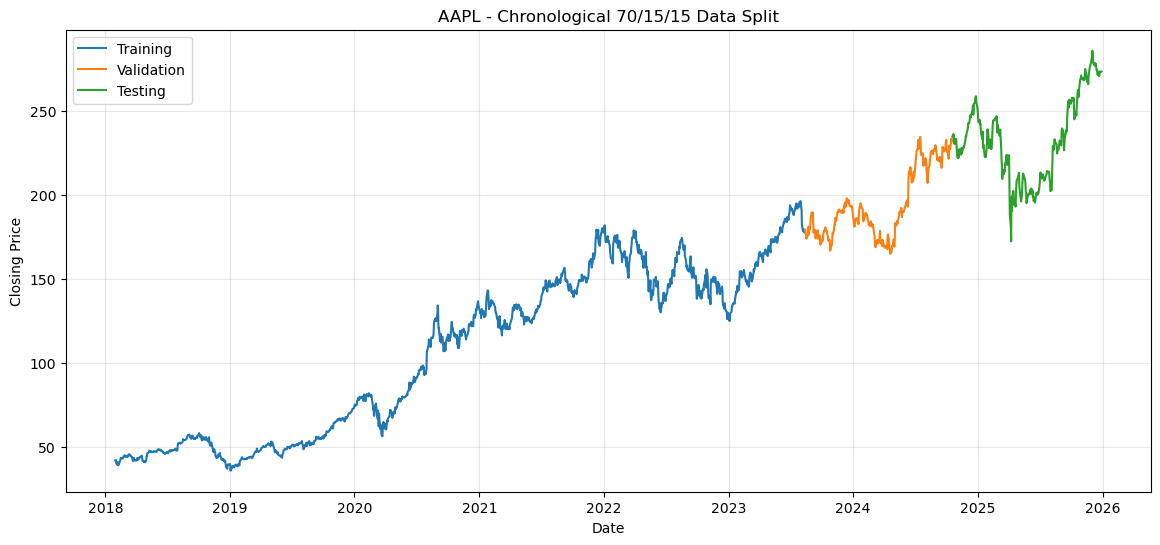

In [157]:
# Plot chronological 70/15/15 data split 
stock_name = "AAPL"

train = splits[stock_name]["train"]
validation = splits[stock_name]["validation"]
test = splits[stock_name]["test"]

plt.figure(figsize=(14, 6))

plt.plot(train["Date"], train["Close"], label="Training")
plt.plot(validation["Date"], validation["Close"], label="Validation")
plt.plot(test["Date"], test["Close"], label="Testing")

plt.title(f"{stock_name} - Chronological 70/15/15 Data Split")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(alpha=0.3)

plt.show()